In [21]:
import torch
import matplotlib.pyplot as plt
import matplotlib.axes as axis
import numpy as np
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import torch.nn as nn
from torchinfo import summary
import statistics
import csv

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [23]:
all, middle_region, southern_region, northern_region = ([] for _ in range(4))
unassigned = 0
with open('embedding_dataset.csv', 'r') as csvfile:
    reader = csv.reader(csvfile)
    next(reader) #skips first line of csv with headers
    for line in reader:
        match line[4]:
            case 'Eastern Temperate Forests':
                middle_region.append(line)
                all.append(line)
            case 'Northwestern Forested Mountains':
                northern_region.append(line)
                all.append(line)
            case 'Temperate Sierras':
                southern_region.append(line)
                all.append(line)
            case 'Great Plains':
                middle_region.append(line)
                all.append(line)
            case 'North American Deserts':
                southern_region.append(line)
                all.append(line)
            case 'Northern Forests':
                northern_region.append(line)
                all.append(line)
            case 'Mediterranean California':
                southern_region.append(line)
                all.append(line)
            case 'Marine West Coast Forests':
                northern_region.append(line)
                all.append(line)
            case 'Tropical Humid Forests':
                southern_region.append(line)
                all.append(line)
            case 'Southern Semi-Arid Highlands':
                northern_region.append(line)
                all.append(line)
            case _:
                all.append(line)
                unassigned += 1
                # print('unplanned classification')

In [24]:
length = len(all)
print(len(northern_region))
print(len(middle_region))
print(len(southern_region))
print(unassigned)

13076
24619
11670
262


In [25]:
genus_toint_dict = {}
species_toint_dict = {}
family_toint_dict = {}
location_toint_dict = {}
genus_tostring_dict = {}
species_tostring_dict = {}
family_tostring_dict = {}
location_tostring_dict = {}

fencode = 0
gencode = 0
sencode = 0
lencode = 0

for entry in all:
    if not entry[0] in family_toint_dict:
        family_toint_dict[entry[0]] = fencode
        family_tostring_dict[fencode] = entry[0]
        fencode += 1
    if not entry[1] in genus_toint_dict:
        genus_toint_dict[entry[1]] = gencode
        genus_tostring_dict[gencode] = entry[1]
        gencode += 1
    if not entry[2] in species_toint_dict:
        species_toint_dict[entry[2]] = sencode
        species_tostring_dict[sencode] = entry[2]
        sencode += 1
    if not entry[4] in location_toint_dict:
        location_toint_dict[entry[4]] = lencode
        location_tostring_dict[lencode] = entry[4]
        lencode += 1
print(len(location_toint_dict))
print(len(genus_toint_dict))
print(len(species_toint_dict))
print(len(family_toint_dict))


11
44
242
5


In [26]:
def encode(dataset):
    family = []
    genus = []
    location = []
    species = []
    year = []
    embeddings_tensor = torch.zeros(len(dataset), 64)
    for i, entry in enumerate(dataset):
        family.append(family_toint_dict[entry[0]])
        genus.append(genus_toint_dict[entry[1]])
        species.append(species_toint_dict[entry[2]])
        year.append(int(entry[3]))
        location.append(location_toint_dict[entry[4]])
        embeddings_tensor[i] = torch.tensor(list(map(float, entry[6:])))

    family_tensor = torch.tensor(family)
    genus_tensor = torch.tensor(genus)
    species_tensor = torch.tensor(species)
    location_tensor = torch.tensor(location)
    year_tensor = torch.tensor(year)

    return family_tensor, genus_tensor, species_tensor, location_tensor, year_tensor, embeddings_tensor

In [27]:
a_family_tensor, a_genus_tensor, a_species_tensor, a_location_tensor, a_year_tensor, a_embeddings_tensor = encode(all)
n_family_tensor, n_genus_tensor, n_species_tensor, n_location_tensor, n_year_tensor, n_embeddings_tensor = encode(northern_region)
m_family_tensor, m_genus_tensor, m_species_tensor, m_location_tensor, m_year_tensor, m_embeddings_tensor = encode(middle_region)
s_family_tensor, s_genus_tensor, s_species_tensor, s_location_tensor, s_year_tensor, s_embeddings_tensor = encode(southern_region)

In [28]:
species_weight = np.array([0.0]*len(species_toint_dict))
label_count = len(species_toint_dict)
for entry in m_species_tensor:
    species_weight[entry] += 1.0

species_weight = torch.tensor(species_weight/length).to(device)

In [39]:
class embed_dataset(torch.utils.data.Dataset):
    def __init__(self, family, genus, species, location, year, embeddings):
        self.family = family
        self.genus = genus
        self.location = location
        self.year = year
        self.species = species
        self.embeddings = embeddings

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        family = self.family[idx]
        genus = self.genus[idx]
        location = self.location[idx]
        species = self.species[idx]
        label = torch.zeros(len(species_weight))
        label[species] = 1
        target = species
        year = self.year[idx]
        embedding = self.embeddings[idx]
        return label, embedding, target


# Create dataset splits
# Set up dataloader for batches
batch_size = 1
a_train_dataset = embed_dataset(a_family_tensor, a_genus_tensor, a_species_tensor, a_location_tensor, a_year_tensor, a_embeddings_tensor)
a_train_dataloader = DataLoader(a_train_dataset, batch_size=batch_size, shuffle=True)

n_train_dataset = embed_dataset(n_family_tensor, n_genus_tensor, n_species_tensor, n_location_tensor, n_year_tensor, n_embeddings_tensor)
n_train_dataloader = DataLoader(n_train_dataset, batch_size=batch_size, shuffle=True)

m_train_dataset = embed_dataset(m_family_tensor, m_genus_tensor, m_species_tensor, m_location_tensor, m_year_tensor, m_embeddings_tensor)
m_train_dataloader = DataLoader(m_train_dataset, batch_size=batch_size, shuffle=True)

s_train_dataset = embed_dataset(s_family_tensor, s_genus_tensor, s_species_tensor, s_location_tensor, s_year_tensor, s_embeddings_tensor)
s_train_dataloader = DataLoader(s_train_dataset, batch_size=batch_size, shuffle=True)

datasets = [n_train_dataloader, m_train_dataloader, s_train_dataloader]

In [30]:
#define model parameters
class TransformerModel(nn.Module):
    def __init__(self, layers=1):
        super().__init__()
        self.t1 = nn.TransformerEncoderLayer(d_model=64, nhead = 8, dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.t2 = nn.TransformerEncoderLayer(d_model=64, nhead = 8, dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.t3 = nn.TransformerEncoderLayer(d_model=64, nhead = 8, dim_feedforward=2048, dropout=0.1, batch_first=True)
        self.l1 = nn.Linear(64, 1024)
        self.l2 = nn.Linear(1024, label_count)
        self.relu = nn.ReLU()
        self.layers = layers
    def forward(self, embedding):
        result = self.t3(self.t2(self.t1(embedding)))
        x = self.relu(self.l1(result))
        return self.l2(x)
class SimpleLinear2(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(64, 1024)
        self.l2 = nn.Linear(1024, 2048)
        self.l3 = nn.Linear(2048, 242)
        self.relu = nn.ReLU()

    def forward(self, embedding):
        x = self.relu(self.l1(embedding))
        x = self.relu(self.l2(x))
        return self.l3(x)

In [31]:
import torch.optim as optim
def training(model, learning_rate, criterion, train_dataloader):
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    losses = []
    for epoch in range(10):
        model.train()
        total_loss = 0
        for label, embedding, target in train_dataloader:
            embedding, label = embedding.to(device), label.to(device)
            optimizer.zero_grad()
            logits = model(embedding)
            loss = criterion(logits, label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_dataloader)
        losses.append(avg_loss)
        print(f"Epoch {epoch+1} - Loss: {avg_loss:.6f}")
    return losses

In [32]:
import torch.optim as optim
accuracies = []
labels = []
learning_rate = 2e-3

linear_a = SimpleLinear2().to(device)
linear_n = SimpleLinear2().to(device)
linear_m = SimpleLinear2().to(device)
linear_s = SimpleLinear2().to(device)


criterion = nn.CrossEntropyLoss(weight=species_weight)
losses_a = training(model=linear_a, learning_rate=learning_rate, criterion=criterion, train_dataloader=a_train_dataloader)
losses_n = training(model=linear_n, learning_rate=learning_rate, criterion=criterion, train_dataloader=n_train_dataloader)
losses_m = training(model=linear_m, learning_rate=learning_rate, criterion=criterion, train_dataloader=m_train_dataloader)
losses_s = training(model=linear_s, learning_rate=learning_rate, criterion=criterion, train_dataloader=s_train_dataloader)

Epoch 1 - Loss: 0.011761
Epoch 2 - Loss: 0.010721
Epoch 3 - Loss: 0.010540
Epoch 4 - Loss: 0.010461
Epoch 5 - Loss: 0.010395
Epoch 6 - Loss: 0.010347
Epoch 7 - Loss: 0.010327
Epoch 8 - Loss: 0.010319
Epoch 9 - Loss: 0.010285
Epoch 10 - Loss: 0.010288
Epoch 1 - Loss: 0.003127
Epoch 2 - Loss: 0.002452
Epoch 3 - Loss: 0.002335
Epoch 4 - Loss: 0.002228
Epoch 5 - Loss: 0.002141
Epoch 6 - Loss: 0.002146
Epoch 7 - Loss: 0.002102
Epoch 8 - Loss: 0.002092
Epoch 9 - Loss: 0.002089
Epoch 10 - Loss: 0.002046
Epoch 1 - Loss: 0.020997
Epoch 2 - Loss: 0.018755
Epoch 3 - Loss: 0.018304
Epoch 4 - Loss: 0.018165
Epoch 5 - Loss: 0.017989
Epoch 6 - Loss: 0.017821
Epoch 7 - Loss: 0.017822
Epoch 8 - Loss: 0.017687
Epoch 9 - Loss: 0.017671
Epoch 10 - Loss: 0.017624
Epoch 1 - Loss: 0.001789
Epoch 2 - Loss: 0.001280
Epoch 3 - Loss: 0.001180
Epoch 4 - Loss: 0.001130
Epoch 5 - Loss: 0.001063
Epoch 6 - Loss: 0.001026
Epoch 7 - Loss: 0.000995
Epoch 8 - Loss: 0.001011
Epoch 9 - Loss: 0.000990
Epoch 10 - Loss: 0.001

In [33]:
def analyze(model, dataloader):
    count = 0
    with torch.no_grad():
        for label, embedding, target in dataloader:
            embedding, label, target = embedding.to(device), label.to(device), target.to(device)
            logits = model(embedding)
            predict = nn.Softmax()
            prediction = predict(logits)
            if(torch.argmax(prediction) == target):
                count += 1
    print(count, len(dataloader))
    print(count/len(dataloader))
    return count/len(dataloader)

In [34]:
accuracies = []
accuracies.append(analyze(linear_a, a_train_dataloader))
accuracies.append(analyze(linear_n, n_train_dataloader))
accuracies.append(analyze(linear_m, m_train_dataloader))
accuracies.append(analyze(linear_s, s_train_dataloader))

/home/april/final_deep/lib/python3.12/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


12011 49627
0.2420255103068894
1945 13076
0.1487457938207403
9291 24619
0.3773914456314229
1318 11670
0.11293916023993145


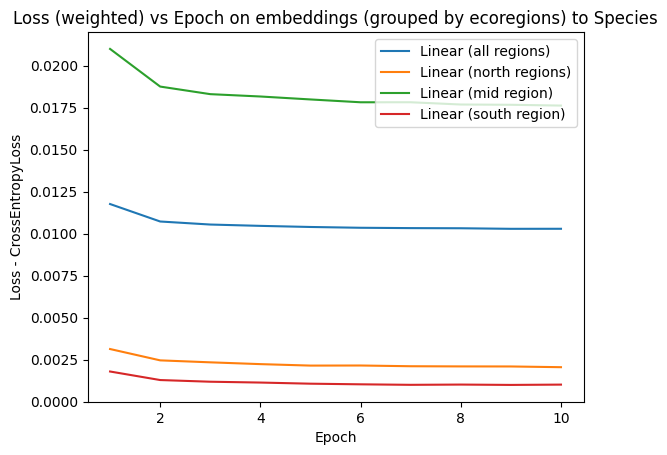

In [35]:
x = list(range(1,11))


plt.plot(x, losses_a, label = "Linear (all regions)")
plt.plot(x, losses_n, label = "Linear (north regions)")
plt.plot(x, losses_m, label = "Linear (mid region)")
plt.plot(x, losses_s, label = "Linear (south region)")
plt.ylabel("Loss - CrossEntropyLoss")
plt.xlabel("Epoch")
plt.legend()
plt.title("Loss (weighted) vs Epoch on embeddings (grouped by ecoregions) to Species")
plt.show()

Text(0.5, 1.0, 'Embeddings (grouped by ecoregions) to species (weighted)')

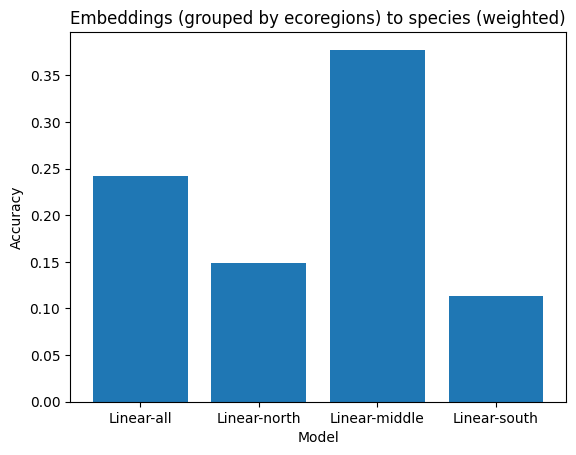

In [36]:
x = ["Linear-all", "Linear-north", "Linear-middle", "Linear-south"]

fig, ax = plt.subplots()
ax.bar(x, accuracies)
ax.set_xlabel("Model")
ax.set_ylabel("Accuracy")
ax.set_title("Embeddings (grouped by ecoregions) to species (weighted)")

In [40]:
def evaluate_versatility(model, learning_rate, criterion):
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
    accuracies = []
    for train_dataloader in datasets:
        tmp = []
        for i in range(5):
            count = 0
            with torch.no_grad():
                for label, embedding, target in train_dataloader:
                    embedding, label, target = embedding.to(device), label.to(device), target.to(device)
                    logits = model(embedding)
                    predict = nn.Softmax()
                    prediction = predict(logits)
                    if(torch.argmax(prediction) == target):
                        count += 1
            tmp.append(count/len(train_dataloader))
            model.train()
            label, embedding, target = next(iter(train_dataloader))
            embedding, label = embedding.to(device), label.to(device)
            optimizer.zero_grad()
            logits = model(embedding)
            loss = criterion(logits, label)
            loss.backward()
            optimizer.step()
        accuracies.append(tmp)
    return accuracies

In [41]:
linear_n_v = evaluate_versatility(linear_n, learning_rate, criterion)
linear_m_v = evaluate_versatility(linear_m, learning_rate, criterion)
linear_s_v = evaluate_versatility(linear_s, learning_rate, criterion)

/home/april/final_deep/lib/python3.12/site-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [42]:
print(linear_n_v)
print(linear_m_v)
print(linear_s_v)

[[0.1487457938207403, 0.1487457938207403, 0.1487457938207403, 0.14920464973998165, 0.14920464973998165], [0.06507169259515008, 0.06564035907226126, 0.06633088265161055, 0.06702140623095983, 0.06734635850359479], [0.0442159383033419, 0.044301628106255354, 0.044301628106255354, 0.044301628106255354, 0.044301628106255354]]
[[0.04963291526460691, 0.04963291526460691, 0.04947996329152646, 0.04955643927806669, 0.04955643927806669], [0.3789755879605183, 0.3789349689264389, 0.37787887404037535, 0.3773914456314229, 0.3771477314269467], [0.03221936589545844, 0.0324764353041988, 0.032647814910025705, 0.032647814910025705, 0.032647814910025705]]
[[0.03686142551238911, 0.03686142551238911, 0.03670847353930866, 0.03670847353930866, 0.03678494952584888], [0.07957268776148503, 0.0796133067955644, 0.07932897355700881, 0.07969454486372314, 0.08010073520451684], [0.11251071122536419, 0.11225364181662383, 0.11216795201371037, 0.11233933161953727, 0.11259640102827763]]


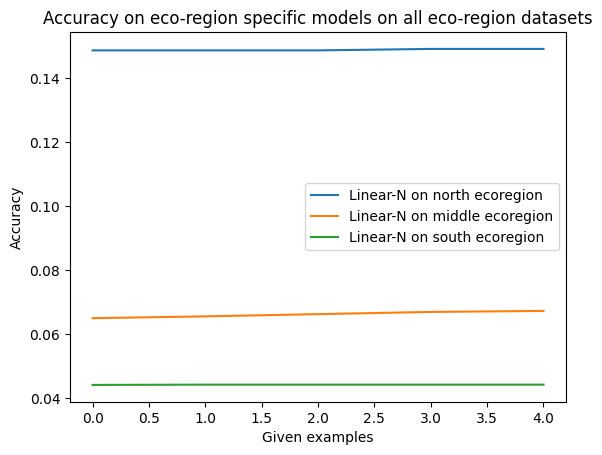

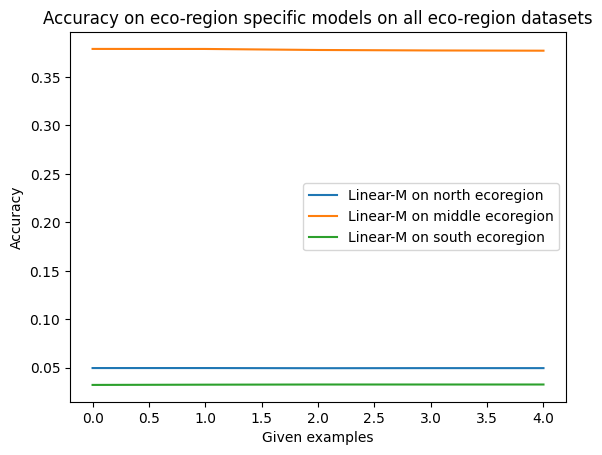

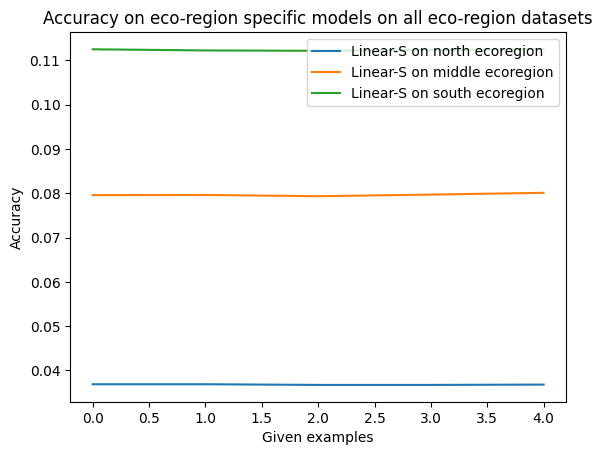

In [44]:
x = list(range(0,5))

plt.plot(x, linear_n_v[0], label = "Linear-N on north ecoregion")
plt.plot(x, linear_n_v[1], label = "Linear-N on middle ecoregion")
plt.plot(x, linear_n_v[2], label = "Linear-N on south ecoregion")
plt.ylabel("Accuracy")
plt.xlabel("Given examples")
plt.legend()
plt.title("Accuracy on eco-region specific models on all eco-region datasets")
plt.show()

plt.plot(x, linear_m_v[0], label = "Linear-M on north ecoregion")
plt.plot(x, linear_m_v[1], label = "Linear-M on middle ecoregion")
plt.plot(x, linear_m_v[2], label = "Linear-M on south ecoregion")
plt.ylabel("Accuracy")
plt.xlabel("Given examples")
plt.legend()
plt.title("Accuracy on eco-region specific models on all eco-region datasets")
plt.show()

plt.plot(x, linear_s_v[0], label = "Linear-S on north ecoregion")
plt.plot(x, linear_s_v[1], label = "Linear-S on middle ecoregion")
plt.plot(x, linear_s_v[2], label = "Linear-S on south ecoregion")
plt.ylabel("Accuracy")
plt.xlabel("Given examples")
plt.legend()
plt.title("Accuracy on eco-region specific models on all eco-region datasets")
plt.show()